In [7]:
import importlib
import pandas as pd
from IPython.display import display
import framework
importlib.reload(framework)
from framework import WheatFramework, generate_group_folds,save_model, save_results, run_fold_with_trainer


CHANGE ACCORDING TO YOUR PATHS !!

In [8]:

# Update paths if different on your machine
excel_path = r"C:\Users\Zetta\Desktop\TARBIL PHENOLOGIC LABEL\labeling.xlsx"
data_path = r"C:\Users\Zetta\Desktop\TARBIL PHENOLOGIC LABEL\data"


Column mapping (expected -> actual):
  1-Ekim -> 1-Ekim
  2 - Çıkış -> 2 - Çıkış
  3 - Çimlenme -> 3 - Çimlenme
  4 - Kardeşlenme -> 4 - Kardeşlenme
  5 - Sapa Kalkma -> 5 - Sapa Kalkma
  6 - Başaklanma -> 6 - Başaklanma
  7 - Çiçeklenme -> 7 - Çiçeklenme
  8 - Olgunlaşma -> 8 - Olgunlaşma
  9 - Hasat -> 9 - Hasat
Searching for images in: C:\Users\Zetta\Desktop\TARBIL PHENOLOGIC LABEL\data
Success! Matched 6902 images.
Total matched images: 6902

Label mapping (encoded -> label):
0 : PS0
1 : PS1
2 : PS2
3 : PS3
4 : PS4
5 : PS5
6 : PS6
7 : PS7

Sample matched paths and labels:


,path,label
0,C:\Users\Zetta\Desktop\TARBIL PHENOLOGIC LABEL...,PS0
1,C:\Users\Zetta\Desktop\TARBIL PHENOLOGIC LABEL...,PS0
2,C:\Users\Zetta\Desktop\TARBIL PHENOLOGIC LABEL...,PS0
3,C:\Users\Zetta\Desktop\TARBIL PHENOLOGIC LABEL...,PS0
4,C:\Users\Zetta\Desktop\TARBIL PHENOLOGIC LABEL...,PS0
5,C:\Users\Zetta\Desktop\TARBIL PHENOLOGIC LABEL...,PS0
6,C:\Users\Zetta\Desktop\TARBIL PHENOLOGIC LABEL...,PS0
7,C:\Users\Zetta\Desktop\TARBIL PHENOLOGIC LABEL...,PS0


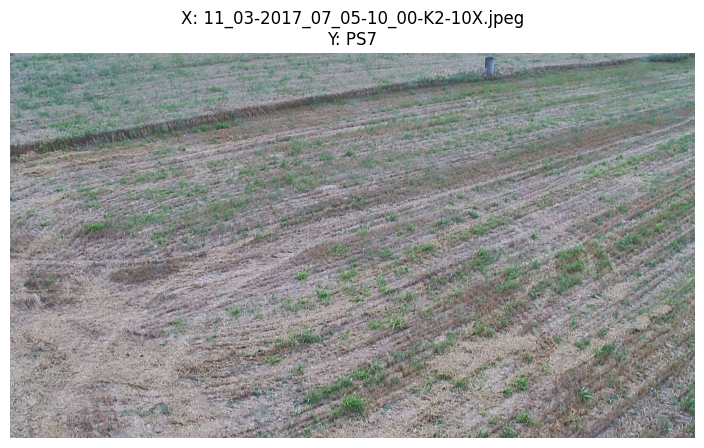

In [11]:

wf = WheatFramework(excel_path=excel_path, root_dir=data_path)

try:
    meta_df = wf.load_and_preprocess()
except Exception as e:
    print("Error loading data:", e)
    meta_df = pd.DataFrame()

if not meta_df.empty:
    X, y, folds = wf.get_splits(meta_df, n_splits=5)
    print(f"Total matched images: {len(X)}")

    # Print label mapping (encoded -> string label)
    classes = list(wf.le.classes_)
    mapping = {i: cls for i, cls in enumerate(classes)}
    print("\nLabel mapping (encoded -> label):")
    for k, v in mapping.items():
        print(k, ":", v)

    print("\nSample matched paths and labels:")
    display(meta_df[['path', 'label']].head(8))

    # Visual verification: display one random sample image and its label
    wf.get_sample(X, y)
else:
    print("No images matched. Review previous prints above for column mapping and search path.")


In [4]:
# Count images by group and stage
import pandas as pd

if 'meta_df' not in globals() or meta_df.empty:
    print("No `meta_df` available. Run the loader cell first (the one that creates `meta_df`).")
else:
    ct = pd.crosstab(meta_df['group_id'], meta_df['label'])
    ct['total'] = ct.sum(axis=1)
    ct = ct.sort_values('total', ascending=False)

    print('\nImages per group × stage (top 20 groups):')
    display(ct.head(20))

    print('\nStage totals:')
    stage_totals = ct.drop(columns=['total']).sum(axis=0).to_frame(name='count')
    display(stage_totals)



Images per group × stage (top 20 groups):


label,PS0,PS1,PS2,PS3,PS4,PS5,PS6,PS7,total
group_id,,,,,,,,,
7,360,48,60,22,56,84,48,112,790
10,124,96,72,112,140,52,100,56,752
6,112,80,124,108,172,12,70,62,740
9,404,68,60,20,60,32,80,0,724
1,80,76,146,60,188,48,32,90,720
2,46,149,84,96,88,36,76,120,695
3,76,86,104,160,104,58,42,64,694
4,28,146,20,74,144,60,52,124,648
8,180,56,68,16,156,84,12,68,640



Stage totals:


,count
label,
PS0,1455
PS1,876
PS2,818
PS3,755
PS4,1204
PS5,484
PS6,550
PS7,760


In [5]:
if 'meta_df' in globals() and not meta_df.empty:
    example_folds = generate_group_folds(meta_df, n_train=8, n_test=2, num_folds=5, random_state=42)
    print('\nGenerated', len(example_folds), 'folds. Sample sizes:')
    for i, (tr, te) in enumerate(example_folds, 1):
        print(f' Fold {i}: train_samples={len(tr)}, test_samples={len(te)}')
else:
    print('meta_df not found — run loader cell first to generate folds.')



Generated 5 folds. Sample sizes:
 Fold 1: train_samples=5388, test_samples=1514
 Fold 2: train_samples=5458, test_samples=1444
 Fold 3: train_samples=5488, test_samples=1414
 Fold 4: train_samples=5560, test_samples=1342
 Fold 5: train_samples=5483, test_samples=1419


YOUR CODE HERE

In [6]:

# ---------------------
# EXAMPLES / TEMPLATES
# ---------------------

# Example: simple sklearn-like trainer function (for models with fit/predict APIs)
# def sklearn_trainer(train_df, test_df, fold_id):
#     # transform paths -> features as needed (e.g., load images and compute embeddings)
#     X_train, y_train = preprocess_paths_to_array(train_df['path'], train_df['label'])
#     X_test, y_test = preprocess_paths_to_array(test_df['path'], test_df['label'])
#     from sklearn.ensemble import RandomForestClassifier
#     model = RandomForestClassifier(n_estimators=100)
#     model.fit(X_train, y_train)
#     preds = model.predict(X_test)
#     # build predictions DataFrame
#     pred_df = pd.DataFrame({'path': test_df['path'], 'true': y_test, 'pred': preds})
#     metrics = {'accuracy': (pred_df['true'] == pred_df['pred']).mean()}
#     return {'model': model, 'predictions': pred_df, 'metrics': metrics}

# Example: PyTorch training skeleton (user must implement dataset, dataloader, model, optimizer)
# def pytorch_trainer(train_df, test_df, fold_id):
#     import torch
#     # implement Dataset that loads images from `path` and returns tensors + labels
#     train_dataset = MyImageDataset(train_df)
#     test_dataset = MyImageDataset(test_df)
#     train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
#     test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32)
#     model = MyNet()
#     optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
#     loss_fn = torch.nn.CrossEntropyLoss()
#     # training loop ...
#     # after training produce preds and metrics
#     pred_df = pd.DataFrame({'path': test_df['path'], 'true': true_labels, 'pred': pred_labels})
#     metrics = {'accuracy': accuracy}
#     return {'model': model, 'predictions': pred_df, 'metrics': metrics}

# Example: YOLO/Ultralytics style (pseudo)
# def yolov5_trainer(train_df, test_df, fold_id):
#     # prepare yaml/train.txt and yaml/val.txt listing image paths
#     # call ultralytics/train.py with appropriate args
#     # after training, load results and return predictions+metrics
#     pass

# ---------------------
# Quick sanity check: create a small set of folds and print counts
